In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import shap
from google.cloud import bigquery
from google.oauth2 import service_account

KEYFILE = r"C:\Users\sansk\Documents\Spring-26\gcp_secret_service\damagereport-499916-f3d6c433577c.json"
PROJECT = "damagereport-499916"

creds = service_account.Credentials.from_service_account_file(
    KEYFILE,
    scopes=["https://www.googleapis.com/auth/cloud-platform"],
)
client = bigquery.Client(project=PROJECT, credentials=creds)

print("Connected")

Connected


In [19]:
query = """
    SELECT
        event_type_group,
        state,
        region,
        decade,
        EXTRACT(MONTH FROM begin_datetime) AS event_month,
        deaths_direct,
        total_damage_2024_usd
    FROM `damagereport-499916.dbt_staging.int_events_enriched`
    WHERE is_pre_standardization = FALSE
      AND event_year < 2026
      AND event_type_group IS NOT NULL
      AND region IS NOT NULL
"""

df = client.query(query).result().to_dataframe()
print(f"Shape: {df.shape}")
print(f"\nFatal events: {(df['deaths_direct'] > 0).sum():,}")
print(f"Non-fatal events: {(df['deaths_direct'] == 0).sum():,}")
print(f"Fatal rate: {(df['deaths_direct'] > 0).mean():.2%}")

C:\Users\sansk\Documents\Spring-26\DamageReport\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Shape: (1720900, 7)

Fatal events: 10,377
Non-fatal events: 1,710,523
Fatal rate: 0.60%


In [20]:
df.head()

,event_type_group,state,region,decade,event_month,deaths_direct,total_damage_2024_usd
0,WINTER_STORM,Wyoming,WEST,2000,2,0,0.0
1,WINTER_STORM,Wyoming,WEST,2000,2,0,0.0
2,WINTER_STORM,Wyoming,WEST,2000,2,0,0.0
3,WINTER_STORM,Wyoming,WEST,2000,2,0,0.0
4,WINTER_STORM,Wyoming,WEST,2000,2,0,0.0


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1720900 entries, 0 to 1720899
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   event_type_group       str    
 1   state                  str    
 2   region                 str    
 3   decade                 Int64  
 4   event_month            Int64  
 5   deaths_direct          Int64  
 6   total_damage_2024_usd  float64
dtypes: Int64(3), float64(1), str(3)
memory usage: 130.8 MB


In [22]:
df.describe()

,decade,event_month,deaths_direct,total_damage_2024_usd
count,1720900.0,1720900.0,1720900.0,1.720900e+06
mean,2006.952926,5.956445,0.01083,5.021615e+05
std,9.39406,3.072513,0.59272,4.520191e+07
min,1990.0,1.0,0.0,0.000000e+00
25%,2000.0,4.0,0.0,0.000000e+00
50%,2010.0,6.0,0.0,0.000000e+00
75%,2010.0,8.0,0.0,0.000000e+00
max,2020.0,12.0,638.0,2.875081e+10


In [23]:
df['is_fatal'] = (df['deaths_direct'] > 0).astype(int)

# One-hot encode categorical features
features = pd.get_dummies(
    df[['event_type_group', 'region', 'decade', 'event_month']],
    columns=['event_type_group', 'region'],
    drop_first=False
)

X = features.astype(float)
y = df['is_fatal']


train_mask = df['decade'] <= 2010
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"Train: {len(X_train):,} rows | Fatal rate: {y_train.mean():.2%}")
print(f"Test:  {len(X_test):,} rows  | Fatal rate: {y_test.mean():.2%}")
print(f"\nFeatures: {X.columns.tolist()}")

Train: 1,330,866 rows | Fatal rate: 0.60%
Test:  390,034 rows  | Fatal rate: 0.62%

Features: ['decade', 'event_month', 'event_type_group_DROUGHT', 'event_type_group_FIRE', 'event_type_group_FLOOD', 'event_type_group_HAIL', 'event_type_group_HEAT', 'event_type_group_HURRICANE', 'event_type_group_MARINE', 'event_type_group_OTHER', 'event_type_group_TORNADO', 'event_type_group_WIND', 'event_type_group_WINTER_STORM', 'region_MIDWEST', 'region_NORTHEAST', 'region_PLAINS', 'region_SOUTH', 'region_SOUTHEAST', 'region_WEST']


In [24]:

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
print("Logistic Regression done")


gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train, y_train)
print("Gradient Boosting done")

C:\Users\sansk\Documents\Spring-26\DamageReport\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression done
Gradient Boosting done


In [25]:
from sklearn.pipeline import Pipeline


scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[['decade', 'event_month']] = scaler.fit_transform(X_train[['decade', 'event_month']])
X_test_scaled[['decade', 'event_month']] = scaler.transform(X_test[['decade', 'event_month']])

# Retrain LR on scaled data
lr = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
lr.fit(X_train_scaled, y_train)
print("Logistic Regression trained ✓")

Logistic Regression trained ✓


In [26]:
from sklearn.metrics import average_precision_score


lr_probs  = lr.predict_proba(X_test_scaled)[:, 1]
gb_probs  = gb.predict_proba(X_test)[:, 1]

# Threshold at 0.5 for F1/classification report
lr_preds = (lr_probs >= 0.5).astype(int)
gb_preds = (gb_probs >= 0.5).astype(int)

for name, probs, preds in [('Logistic Regression', lr_probs, lr_preds),
                            ('Gradient Boosting',   gb_probs, gb_preds)]:
    print(f"\n{'='*45}")
    print(f" {name}")
    print(f"{'='*45}")
    print(f"  PR-AUC  : {average_precision_score(y_test, probs):.4f}")
    print(f"  ROC-AUC : {roc_auc_score(y_test, probs):.4f}")
    print(f"\n{classification_report(y_test, preds, target_names=['Non-fatal','Fatal'])}")


 Logistic Regression
  PR-AUC  : 0.0695
  ROC-AUC : 0.8419

              precision    recall  f1-score   support

   Non-fatal       1.00      0.81      0.89    387621
       Fatal       0.02      0.71      0.04      2413

    accuracy                           0.81    390034
   macro avg       0.51      0.76      0.47    390034
weighted avg       0.99      0.81      0.89    390034


 Gradient Boosting
  PR-AUC  : 0.1225
  ROC-AUC : 0.8508

              precision    recall  f1-score   support

   Non-fatal       0.99      1.00      1.00    387621
       Fatal       0.33      0.08      0.13      2413

    accuracy                           0.99    390034
   macro avg       0.66      0.54      0.56    390034
weighted avg       0.99      0.99      0.99    390034



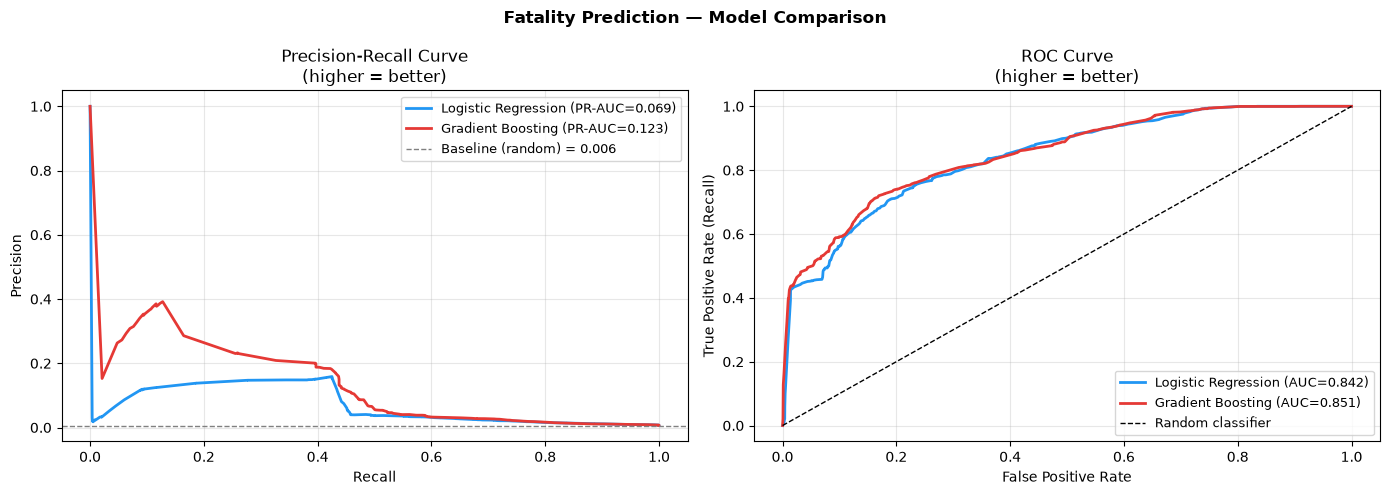

In [27]:
from sklearn.metrics import precision_recall_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# PR curves
for name, probs, color in [('Logistic Regression', lr_probs, '#2196F3'),
                             ('Gradient Boosting',   gb_probs, '#E53935')]:
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    ax1.plot(rec, prec, color=color, linewidth=2, label=f'{name} (PR-AUC={ap:.3f})')

ax1.axhline(y_test.mean(), color='grey', linestyle='--', linewidth=1, label=f'Baseline (random) = {y_test.mean():.3f}')
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Curve\n(higher = better)')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# ROC curves
from sklearn.metrics import roc_curve
for name, probs, color in [('Logistic Regression', lr_probs, '#2196F3'),
                             ('Gradient Boosting',   gb_probs, '#E53935')]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax2.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')

ax2.plot([0,1], [0,1], 'k--', linewidth=1, label='Random classifier')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate (Recall)')
ax2.set_title('ROC Curve\n(higher = better)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle('Fatality Prediction — Model Comparison', fontweight='bold')
plt.tight_layout()
plt.show()


Logistic Regression @ threshold=0.83
              precision    recall  f1-score   support

   Non-fatal       1.00      0.95      0.97    387621
       Fatal       0.05      0.45      0.09      2413

    accuracy                           0.94    390034
   macro avg       0.52      0.70      0.53    390034
weighted avg       0.99      0.94      0.97    390034


Gradient Boosting @ threshold=0.02
              precision    recall  f1-score   support

   Non-fatal       1.00      0.94      0.97    387621
       Fatal       0.05      0.52      0.09      2413

    accuracy                           0.94    390034
   macro avg       0.52      0.73      0.53    390034
weighted avg       0.99      0.94      0.96    390034



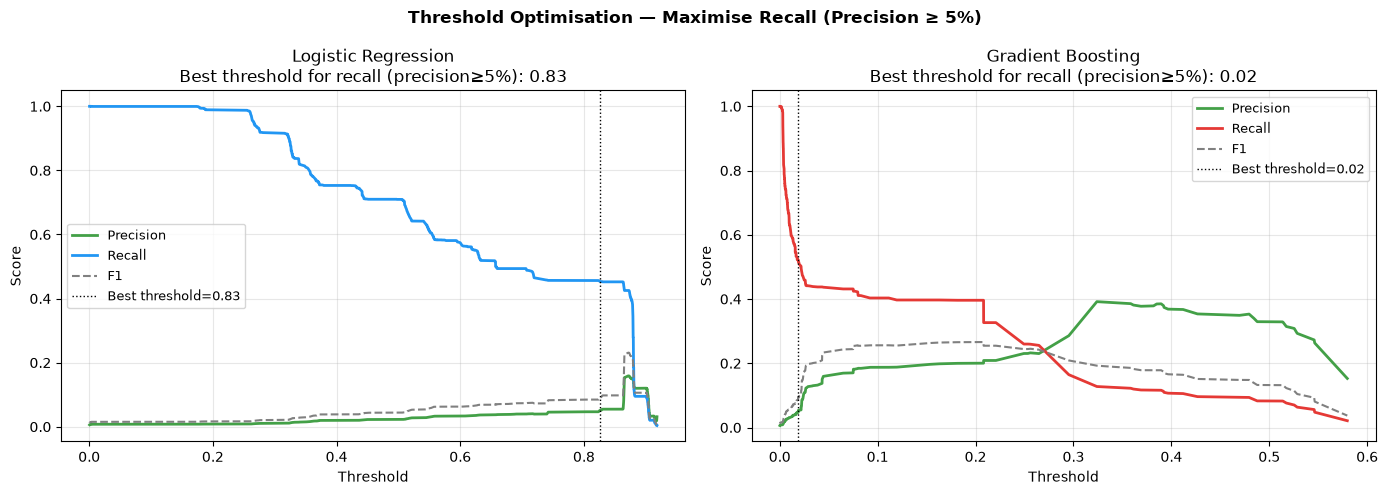

In [28]:
from sklearn.metrics import precision_recall_curve, f1_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, probs, color) in enumerate([('Logistic Regression', lr_probs, '#2196F3'),
                                              ('Gradient Boosting',   gb_probs, '#E53935')]):
    prec, rec, thresholds = precision_recall_curve(y_test, probs)
    f1_scores = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)

    
    valid = prec[:-1] >= 0.05
    best_idx = np.argmax(rec[:-1] * valid) if valid.any() else np.argmax(rec[:-1])
    best_thresh = thresholds[best_idx]

    axes[idx].plot(thresholds, prec[:-1], color='#43A047', linewidth=2, label='Precision')
    axes[idx].plot(thresholds, rec[:-1],  color=color,    linewidth=2, label='Recall')
    axes[idx].plot(thresholds, f1_scores, color='grey',   linewidth=1.5, linestyle='--', label='F1')
    axes[idx].axvline(best_thresh, color='black', linewidth=1, linestyle=':', label=f'Best threshold={best_thresh:.2f}')
    axes[idx].set_xlabel('Threshold')
    axes[idx].set_ylabel('Score')
    axes[idx].set_title(f'{name}\nBest threshold for recall (precision≥5%): {best_thresh:.2f}')
    axes[idx].legend(fontsize=9)
    axes[idx].grid(alpha=0.3)

    print(f"\n{name} @ threshold={best_thresh:.2f}")
    preds_opt = (probs >= best_thresh).astype(int)
    print(classification_report(y_test, preds_opt, target_names=['Non-fatal', 'Fatal']))

plt.suptitle('Threshold Optimisation — Maximise Recall (Precision ≥ 5%)', fontweight='bold')
plt.tight_layout()
plt.show()

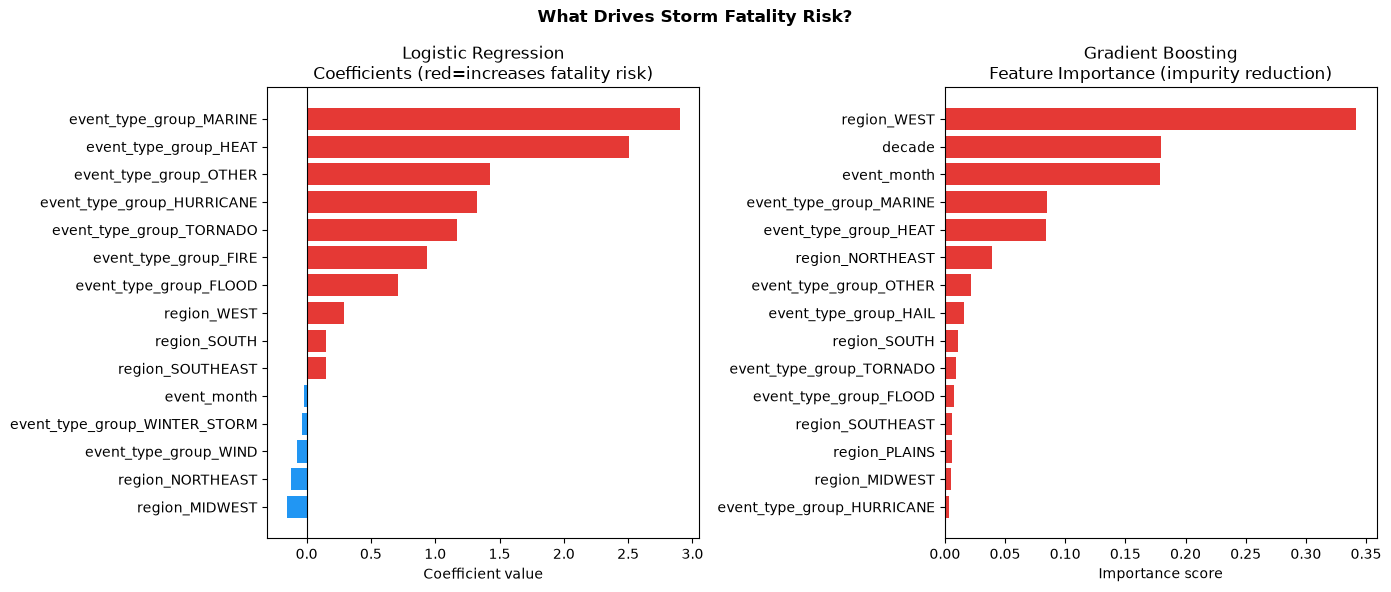

In [29]:
feature_names = X_train.columns.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Logistic Regression coefficients
lr_imp = pd.Series(lr.coef_[0], index=feature_names).sort_values()
colors_lr = ['#E53935' if v > 0 else '#2196F3' for v in lr_imp.tail(15).values]
ax1.barh(lr_imp.tail(15).index, lr_imp.tail(15).values, color=colors_lr)
ax1.set_title('Logistic Regression\nCoefficients (red=increases fatality risk)')
ax1.set_xlabel('Coefficient value')
ax1.axvline(0, color='black', linewidth=0.8)

# Gradient Boosting feature importance
gb_imp = pd.Series(gb.feature_importances_, index=feature_names).sort_values(ascending=True).tail(15)
ax2.barh(gb_imp.index, gb_imp.values, color='#E53935')
ax2.set_title('Gradient Boosting\nFeature Importance (impurity reduction)')
ax2.set_xlabel('Importance score')

plt.suptitle('What Drives Storm Fatality Risk?', fontweight='bold')
plt.tight_layout()
plt.show()

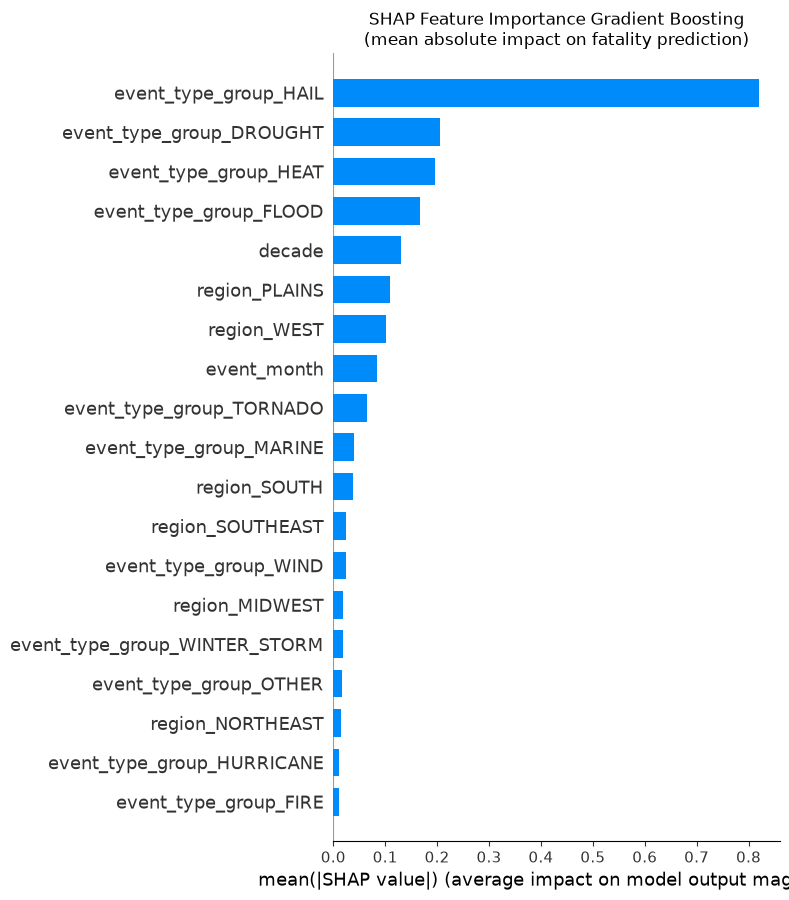

In [31]:
explainer = shap.TreeExplainer(gb)
# Sample 2000 rows 
sample = X_test.sample(10000, random_state=42)
shap_values = explainer.shap_values(sample)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, sample, plot_type='bar', show=False)
plt.title('SHAP Feature Importance Gradient Boosting\n(mean absolute impact on fatality prediction)')
plt.tight_layout()
plt.show()

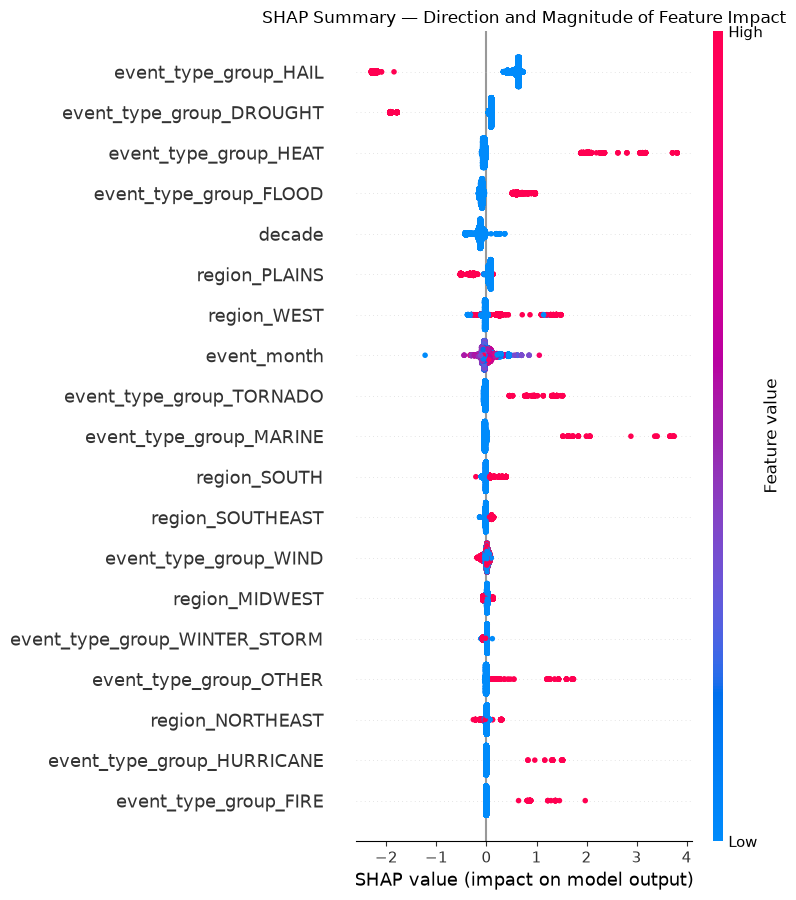

In [32]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, sample, show=False)
plt.title('SHAP Summary — Direction and Magnitude of Feature Impact')
plt.tight_layout()
plt.show()

In [33]:
lag_query = """
    SELECT
        state,
        event_year,
        COUNT(*)                        AS state_year_event_count,
        SUM(deaths_direct)              AS state_year_deaths,
        SUM(total_damage_2024_usd)      AS state_year_damage
    FROM `damagereport-499916.dbt_staging.int_events_enriched`
    WHERE is_pre_standardization = FALSE
      AND event_year < 2026
      AND state IS NOT NULL
    GROUP BY state, event_year
    ORDER BY state, event_year
"""

df_state_year = client.query(lag_query).result().to_dataframe()

# Create lag features shift each state's metrics forward by 1 year
# So 2004 values become the "prior year" feature for 2005 events
df_state_year = df_state_year.sort_values(['state', 'event_year'])
df_state_year['lag_event_count']  = df_state_year.groupby('state')['state_year_event_count'].shift(1)
df_state_year['lag_deaths']       = df_state_year.groupby('state')['state_year_deaths'].shift(1)
df_state_year['lag_damage']       = df_state_year.groupby('state')['state_year_damage'].shift(1)


df_lag = df_state_year[['state', 'event_year', 'lag_event_count', 'lag_deaths', 'lag_damage']]

print(f"Lag table shape: {df_lag.shape}")
print(f"Null lag rows (first year per state, expected): {df_lag['lag_event_count'].isna().sum()}")
df_lag.head(10)

C:\Users\sansk\Documents\Spring-26\DamageReport\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Lag table shape: (1944, 5)
Null lag rows (first year per state, expected): 69


,state,event_year,lag_event_count,lag_deaths,lag_damage
0,Alabama,1996,<NA>,<NA>,NaN
1,Alabama,1997,921,16,1.690896e+08
2,Alabama,1998,731,3,1.664296e+08
3,Alabama,1999,1001,50,1.510256e+09
4,Alabama,2000,714,11,2.203072e+07
5,Alabama,2001,1008,21,9.724815e+07
6,Alabama,2002,765,14,4.741203e+07
7,Alabama,2003,759,21,6.409787e+07
8,Alabama,2004,1143,4,1.765749e+09
9,Alabama,2005,848,5,4.363681e+09


In [35]:
print(df.columns.tolist())

['event_type_group', 'state', 'region', 'decade', 'event_month', 'deaths_direct', 'total_damage_2024_usd', 'is_fatal']


In [36]:
query = """
    SELECT
        event_type_group,
        state,
        region,
        decade,
        event_year,
        EXTRACT(MONTH FROM begin_datetime) AS event_month,
        deaths_direct,
        total_damage_2024_usd
    FROM `damagereport-499916.dbt_staging.int_events_enriched`
    WHERE is_pre_standardization = FALSE
      AND event_year < 2026
      AND event_type_group IS NOT NULL
      AND region IS NOT NULL
"""

df = client.query(query).result().to_dataframe()
df['is_fatal'] = (df['deaths_direct'] > 0).astype(int)

print(f"Shape: {df.shape}")
print(df.columns.tolist())

C:\Users\sansk\Documents\Spring-26\DamageReport\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Shape: (1720900, 9)
['event_type_group', 'state', 'region', 'decade', 'event_year', 'event_month', 'deaths_direct', 'total_damage_2024_usd', 'is_fatal']


In [37]:
df = df.merge(
    df_lag,
    on=['state', 'event_year'],
    how='left'
)


df['lag_event_count'] = df['lag_event_count'].fillna(0)
df['lag_deaths']      = df['lag_deaths'].fillna(0)
df['lag_damage']      = df['lag_damage'].fillna(0)

print(f"Shape after join: {df.shape}")
print(f"Null check:\n{df[['lag_event_count','lag_deaths','lag_damage']].isna().sum()}")
df[['state', 'event_year', 'lag_event_count', 'lag_deaths', 'lag_damage']].head()

Shape after join: (1720900, 12)
Null check:
lag_event_count    0
lag_deaths         0
lag_damage         0
dtype: int64


,state,event_year,lag_event_count,lag_deaths,lag_damage
0,Wyoming,2000,378,6,6548681.53
1,Wyoming,2000,378,6,6548681.53
2,Wyoming,2000,378,6,6548681.53
3,Wyoming,2000,378,6,6548681.53
4,Wyoming,2000,378,6,6548681.53


In [38]:
df['is_fatal'] = (df['deaths_direct'] > 0).astype(int)

features = pd.get_dummies(
    df[['event_type_group', 'region', 'decade', 'event_month',
        'lag_event_count', 'lag_deaths', 'lag_damage']],
    columns=['event_type_group', 'region'],
    drop_first=False
)

X = features.astype(float)
y = df['is_fatal']


train_mask = df['decade'] <= 2010
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"Train: {len(X_train):,} rows | Fatal rate: {y_train.mean():.2%}")
print(f"Test:  {len(X_test):,} rows  | Fatal rate: {y_test.mean():.2%}")
print(f"Features ({len(X.columns)}): {X.columns.tolist()}")

Train: 1,330,866 rows | Fatal rate: 0.60%
Test:  390,034 rows  | Fatal rate: 0.62%
Features (22): ['decade', 'event_month', 'lag_event_count', 'lag_deaths', 'lag_damage', 'event_type_group_DROUGHT', 'event_type_group_FIRE', 'event_type_group_FLOOD', 'event_type_group_HAIL', 'event_type_group_HEAT', 'event_type_group_HURRICANE', 'event_type_group_MARINE', 'event_type_group_OTHER', 'event_type_group_TORNADO', 'event_type_group_WIND', 'event_type_group_WINTER_STORM', 'region_MIDWEST', 'region_NORTHEAST', 'region_PLAINS', 'region_SOUTH', 'region_SOUTHEAST', 'region_WEST']


In [46]:
from sklearn.pipeline import Pipeline


scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

cols_to_scale = ['decade', 'event_month', 'lag_event_count', 'lag_deaths', 'lag_damage']
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

lr = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
lr.fit(X_train_scaled, y_train)
print("Logistic Regression done")


Logistic Regression done


In [40]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train, y_train)
print("Gradient Boosting done")

Gradient Boosting done


In [47]:
from sklearn.metrics import average_precision_score


lr_probs  = lr.predict_proba(X_test_scaled)[:, 1]
gb_probs  = gb.predict_proba(X_test)[:, 1]

# Threshold at 0.5 for F1/classification report
lr_preds = (lr_probs >= 0.5).astype(int)
gb_preds = (gb_probs >= 0.5).astype(int)

for name, probs, preds in [('Logistic Regression', lr_probs, lr_preds),
                            ('Gradient Boosting',   gb_probs, gb_preds)]:
    print(f"\n{'='*45}")
    print(f" {name}")
    print(f"{'='*45}")
    print(f"  PR-AUC  : {average_precision_score(y_test, probs):.4f}")
    print(f"  ROC-AUC : {roc_auc_score(y_test, probs):.4f}")
    print(f"\n{classification_report(y_test, preds, target_names=['Non-fatal','Fatal'])}")


 Logistic Regression
  PR-AUC  : 0.1348
  ROC-AUC : 0.8454

              precision    recall  f1-score   support

   Non-fatal       1.00      0.82      0.90    387621
       Fatal       0.02      0.70      0.05      2413

    accuracy                           0.82    390034
   macro avg       0.51      0.76      0.47    390034
weighted avg       0.99      0.82      0.89    390034


 Gradient Boosting
  PR-AUC  : 0.0639
  ROC-AUC : 0.8533

              precision    recall  f1-score   support

   Non-fatal       0.99      1.00      1.00    387621
       Fatal       0.18      0.09      0.12      2413

    accuracy                           0.99    390034
   macro avg       0.59      0.54      0.56    390034
weighted avg       0.99      0.99      0.99    390034



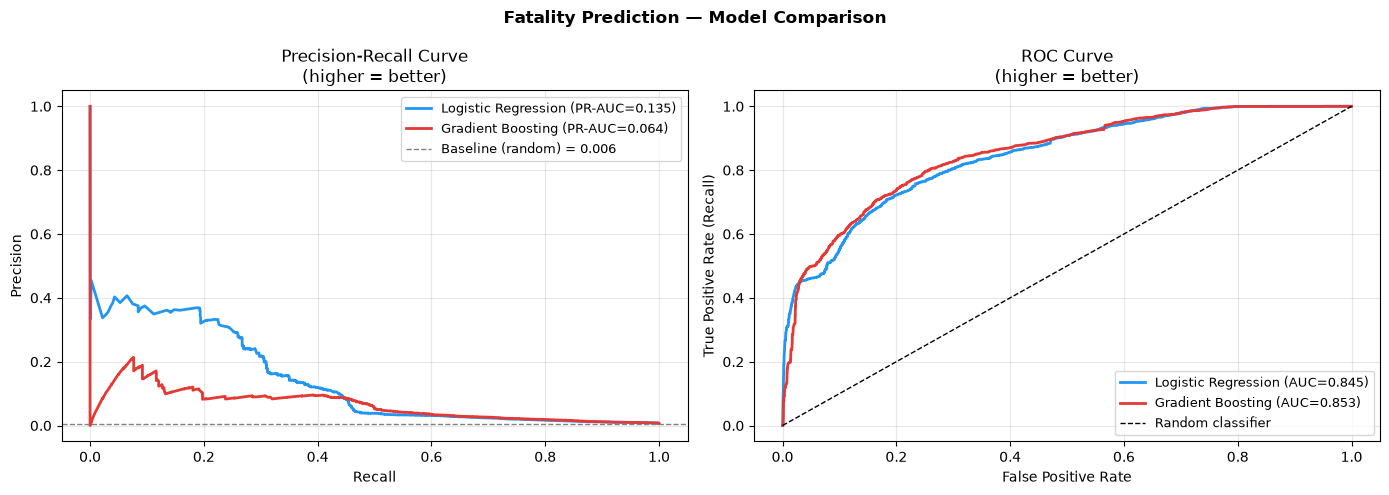

In [48]:
from sklearn.metrics import precision_recall_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# PR curves
for name, probs, color in [('Logistic Regression', lr_probs, '#2196F3'),
                             ('Gradient Boosting',   gb_probs, '#E53935')]:
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    ax1.plot(rec, prec, color=color, linewidth=2, label=f'{name} (PR-AUC={ap:.3f})')

ax1.axhline(y_test.mean(), color='grey', linestyle='--', linewidth=1, label=f'Baseline (random) = {y_test.mean():.3f}')
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Curve\n(higher = better)')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# ROC curves
from sklearn.metrics import roc_curve
for name, probs, color in [('Logistic Regression', lr_probs, '#2196F3'),
                             ('Gradient Boosting',   gb_probs, '#E53935')]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax2.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')

ax2.plot([0,1], [0,1], 'k--', linewidth=1, label='Random classifier')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate (Recall)')
ax2.set_title('ROC Curve\n(higher = better)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle('Fatality Prediction — Model Comparison', fontweight='bold')
plt.tight_layout()
plt.show()


Logistic Regression @ threshold=0.82
              precision    recall  f1-score   support

   Non-fatal       1.00      0.95      0.97    387621
       Fatal       0.05      0.46      0.09      2413

    accuracy                           0.94    390034
   macro avg       0.52      0.70      0.53    390034
weighted avg       0.99      0.94      0.96    390034


Gradient Boosting @ threshold=0.02
              precision    recall  f1-score   support

   Non-fatal       1.00      0.94      0.97    387621
       Fatal       0.05      0.51      0.09      2413

    accuracy                           0.94    390034
   macro avg       0.52      0.73      0.53    390034
weighted avg       0.99      0.94      0.96    390034



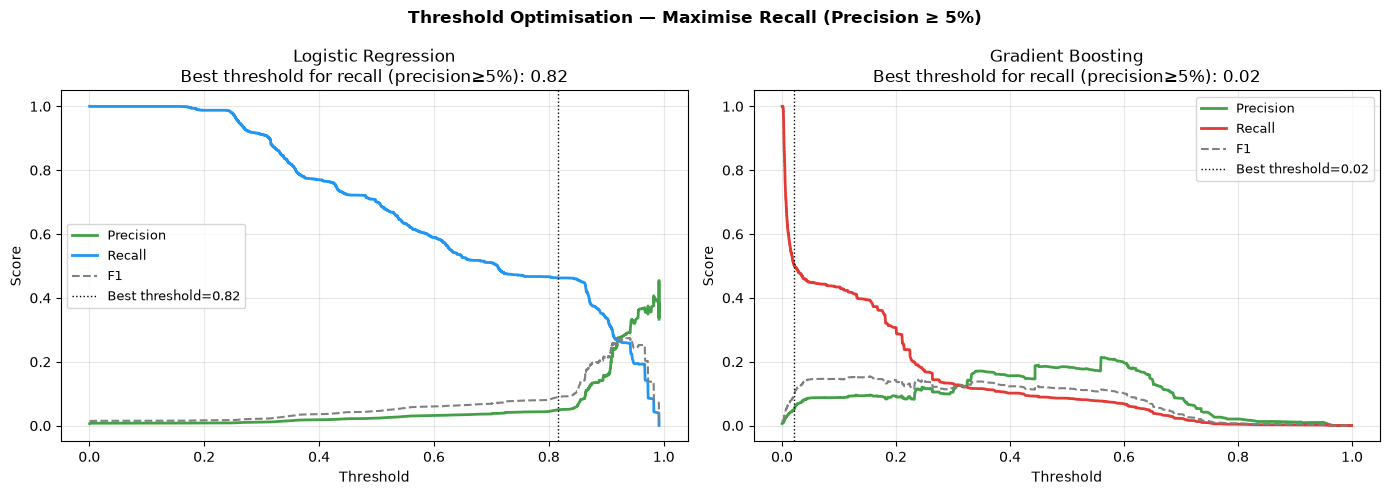

In [49]:
from sklearn.metrics import precision_recall_curve, f1_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, probs, color) in enumerate([('Logistic Regression', lr_probs, '#2196F3'),
                                              ('Gradient Boosting',   gb_probs, '#E53935')]):
    prec, rec, thresholds = precision_recall_curve(y_test, probs)
    f1_scores = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)

    
    valid = prec[:-1] >= 0.05
    best_idx = np.argmax(rec[:-1] * valid) if valid.any() else np.argmax(rec[:-1])
    best_thresh = thresholds[best_idx]

    axes[idx].plot(thresholds, prec[:-1], color='#43A047', linewidth=2, label='Precision')
    axes[idx].plot(thresholds, rec[:-1],  color=color,    linewidth=2, label='Recall')
    axes[idx].plot(thresholds, f1_scores, color='grey',   linewidth=1.5, linestyle='--', label='F1')
    axes[idx].axvline(best_thresh, color='black', linewidth=1, linestyle=':', label=f'Best threshold={best_thresh:.2f}')
    axes[idx].set_xlabel('Threshold')
    axes[idx].set_ylabel('Score')
    axes[idx].set_title(f'{name}\nBest threshold for recall (precision≥5%): {best_thresh:.2f}')
    axes[idx].legend(fontsize=9)
    axes[idx].grid(alpha=0.3)

    print(f"\n{name} @ threshold={best_thresh:.2f}")
    preds_opt = (probs >= best_thresh).astype(int)
    print(classification_report(y_test, preds_opt, target_names=['Non-fatal', 'Fatal']))

plt.suptitle('Threshold Optimisation — Maximise Recall (Precision ≥ 5%)', fontweight='bold')
plt.tight_layout()
plt.show()

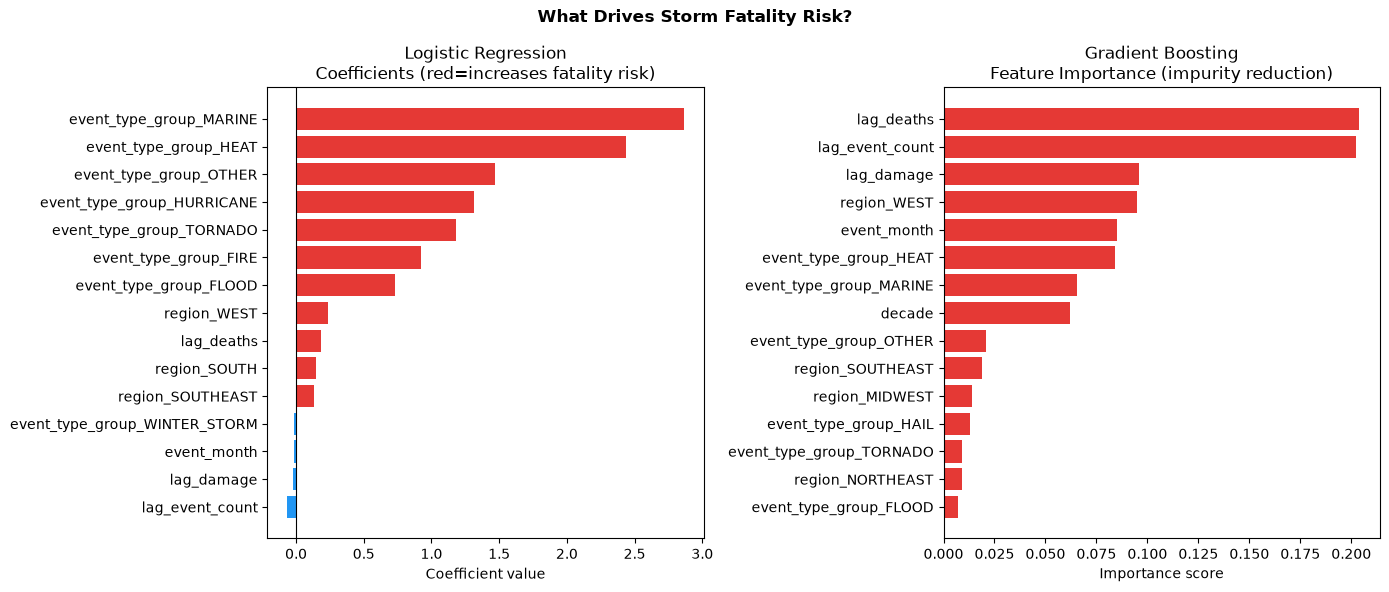

In [50]:
feature_names = X_train.columns.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Logistic Regression coefficients
lr_imp = pd.Series(lr.coef_[0], index=feature_names).sort_values()
colors_lr = ['#E53935' if v > 0 else '#2196F3' for v in lr_imp.tail(15).values]
ax1.barh(lr_imp.tail(15).index, lr_imp.tail(15).values, color=colors_lr)
ax1.set_title('Logistic Regression\nCoefficients (red=increases fatality risk)')
ax1.set_xlabel('Coefficient value')
ax1.axvline(0, color='black', linewidth=0.8)

# Gradient Boosting feature importance
gb_imp = pd.Series(gb.feature_importances_, index=feature_names).sort_values(ascending=True).tail(15)
ax2.barh(gb_imp.index, gb_imp.values, color='#E53935')
ax2.set_title('Gradient Boosting\nFeature Importance (impurity reduction)')
ax2.set_xlabel('Importance score')

plt.suptitle('What Drives Storm Fatality Risk?', fontweight='bold')
plt.tight_layout()
plt.show()

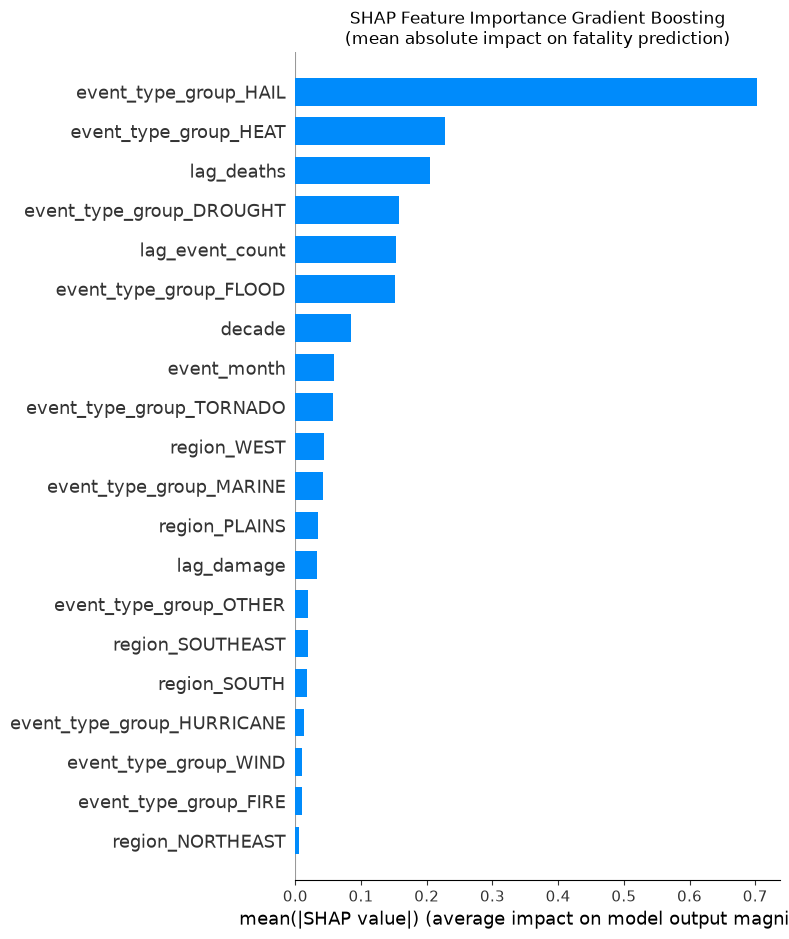

In [45]:
explainer = shap.TreeExplainer(gb)
# Sample 2000 rows 
sample = X_test.sample(10000, random_state=42)
shap_values = explainer.shap_values(sample)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, sample, plot_type='bar', show=False)
plt.title('SHAP Feature Importance Gradient Boosting\n(mean absolute impact on fatality prediction)')
plt.tight_layout()
plt.show()

In [52]:

train_df = df[df['decade'] <= 2010].copy()
test_df  = df[df['decade'] > 2010].copy()

global_mean = train_df['is_fatal'].mean()

type_rates   = train_df.groupby('event_type_group')['is_fatal'].mean().rename('type_fatality_rate')
region_rates = train_df.groupby('region')['is_fatal'].mean().rename('region_fatality_rate')
decade_rates = train_df.groupby('decade')['is_fatal'].mean().rename('decade_fatality_rate')

for split_df in [train_df, test_df]:
    split_df['type_fatality_rate']   = split_df['event_type_group'].map(type_rates).fillna(global_mean)
    split_df['region_fatality_rate'] = split_df['region'].map(region_rates).fillna(global_mean)
    split_df['decade_fatality_rate'] = split_df['decade'].map(decade_rates).fillna(global_mean)

print("Target encoding computed on training set")
print("\nEvent type fatality rates (from training data):")
print(type_rates.sort_values(ascending=False).round(4))

Target encoding computed on training set

Event type fatality rates (from training data):
event_type_group
MARINE          0.0790
HEAT            0.0505
OTHER           0.0217
HURRICANE       0.0189
TORNADO         0.0136
FIRE            0.0117
FLOOD           0.0088
WINTER_STORM    0.0041
WIND            0.0041
HAIL            0.0000
DROUGHT         0.0000
Name: type_fatality_rate, dtype: float64


In [53]:
feature_cols = ['event_month', 'decade',
                'lag_event_count', 'lag_deaths', 'lag_damage',
                'type_fatality_rate', 'region_fatality_rate', 'decade_fatality_rate']

X_train_custom = train_df[feature_cols].astype(float)
X_test_custom  = test_df[feature_cols].astype(float)
y_train_custom = train_df['is_fatal']
y_test_custom  = test_df['is_fatal']

# Scale all features 
scaler_custom = StandardScaler()
X_train_custom_scaled = pd.DataFrame(
    scaler_custom.fit_transform(X_train_custom),
    columns=feature_cols
)
X_test_custom_scaled = pd.DataFrame(
    scaler_custom.transform(X_test_custom),
    columns=feature_cols
)

# Train both LR and GB on custom features
lr_custom = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
lr_custom.fit(X_train_custom_scaled, y_train_custom)
print("Custom LR done")

gb_custom = GradientBoostingClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    subsample=0.8, random_state=42
)
gb_custom.fit(X_train_custom, y_train_custom)
print("Custom GB done")

Custom LR done
Custom GB done


In [54]:
from sklearn.metrics import average_precision_score

results = []

for name, probs, y_test_used in [
    ('LR — one-hot + lag',      lr.predict_proba(X_test_scaled)[:, 1],         y_test),
    ('GB — one-hot + lag',      gb.predict_proba(X_test)[:, 1],                y_test),
    ('LR — target encoded',     lr_custom.predict_proba(X_test_custom_scaled)[:, 1], y_test_custom),
    ('GB — target encoded',     gb_custom.predict_proba(X_test_custom)[:, 1],  y_test_custom),
]:
    pr_auc  = average_precision_score(y_test_used, probs)
    roc_auc = roc_auc_score(y_test_used, probs)
    
    
    prec, rec, thresholds = precision_recall_curve(y_test_used, probs)
    valid = prec[:-1] >= 0.05
    best_idx = np.argmax(rec[:-1] * valid) if valid.any() else np.argmax(rec[:-1])
    best_thresh = thresholds[best_idx]
    preds_opt = (probs >= best_thresh).astype(int)
    recall_opt = rec[best_idx]
    
    results.append({
        'Model': name,
        'PR-AUC': round(pr_auc, 4),
        'ROC-AUC': round(roc_auc, 4),
        'Best threshold': round(best_thresh, 2),
        'Recall @ threshold': round(recall_opt, 3)
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())

                     PR-AUC  ROC-AUC  Best threshold  Recall @ threshold
Model                                                                   
LR — one-hot + lag   0.1348   0.8454            0.82               0.462
GB — one-hot + lag   0.0639   0.8533            0.02               0.511
LR — target encoded  0.1015   0.8236            0.89               0.455
GB — target encoded  0.0991   0.8011            0.03               0.433


In [55]:
# One-hot encode categoricals
ohe_features = pd.get_dummies(
    df[['event_type_group', 'region', 'decade', 'event_month',
        'lag_event_count', 'lag_deaths', 'lag_damage']],
    columns=['event_type_group', 'region'],
    drop_first=False
).astype(float)

# Add target encoded rates as additional features
ohe_features['type_fatality_rate']   = df['event_type_group'].map(type_rates).fillna(global_mean)
ohe_features['region_fatality_rate'] = df['region'].map(region_rates).fillna(global_mean)
ohe_features['decade_fatality_rate'] = df['decade'].map(decade_rates).fillna(global_mean)

X_combined = ohe_features
y_combined  = df['is_fatal']

train_mask = df['decade'] <= 2010
X_train_c, X_test_c = X_combined[train_mask], X_combined[~train_mask]
y_train_c, y_test_c = y_combined[train_mask], y_combined[~train_mask]

# Scale numeric + lag + target encoded cols only
cols_to_scale = ['decade', 'event_month', 'lag_event_count', 'lag_deaths',
                 'lag_damage', 'type_fatality_rate', 'region_fatality_rate', 'decade_fatality_rate']

scaler_c = StandardScaler()
X_train_c_scaled = X_train_c.copy()
X_test_c_scaled  = X_test_c.copy()
X_train_c_scaled[cols_to_scale] = scaler_c.fit_transform(X_train_c[cols_to_scale])
X_test_c_scaled[cols_to_scale]  = scaler_c.transform(X_test_c[cols_to_scale])

print(f"Features: {X_combined.shape[1]} total ({len(cols_to_scale)} scaled)")

lr_combined = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
lr_combined.fit(X_train_c_scaled, y_train_c)
print("Combined LR trained")

gb_combined = GradientBoostingClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    subsample=0.8, random_state=42
)
gb_combined.fit(X_train_c, y_train_c)
print("Combined GB trained")

Features: 25 total (8 scaled)
Combined LR trained
Combined GB trained


In [56]:
results = []

for name, probs, y_t in [
    ('LR — one-hot + lag',       lr.predict_proba(X_test_scaled)[:, 1],              y_test),
    ('GB — one-hot + lag',       gb.predict_proba(X_test)[:, 1],                     y_test),
    ('LR — target encoded',      lr_custom.predict_proba(X_test_custom_scaled)[:, 1],y_test_custom),
    ('GB — target encoded',      gb_custom.predict_proba(X_test_custom)[:, 1],       y_test_custom),
    ('LR — combined',            lr_combined.predict_proba(X_test_c_scaled)[:, 1],   y_test_c),
    ('GB — combined',            gb_combined.predict_proba(X_test_c)[:, 1],          y_test_c),
]:
    pr_auc  = average_precision_score(y_t, probs)
    roc_auc = roc_auc_score(y_t, probs)

    prec, rec, thresholds = precision_recall_curve(y_t, probs)
    valid    = prec[:-1] >= 0.05
    best_idx = np.argmax(rec[:-1] * valid) if valid.any() else np.argmax(rec[:-1])
    best_thresh  = thresholds[best_idx]
    recall_opt   = rec[best_idx]

    results.append({
        'Model'              : name,
        'PR-AUC'             : round(pr_auc, 4),
        'ROC-AUC'            : round(roc_auc, 4),
        'Best threshold'     : round(best_thresh, 2),
        'Recall @ threshold' : round(recall_opt, 3)
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())

                     PR-AUC  ROC-AUC  Best threshold  Recall @ threshold
Model                                                                   
LR — one-hot + lag   0.1348   0.8454            0.82               0.462
GB — one-hot + lag   0.0639   0.8533            0.02               0.511
LR — target encoded  0.1015   0.8236            0.89               0.455
GB — target encoded  0.0991   0.8011            0.03               0.433
LR — combined        0.1349   0.8457            0.84               0.462
GB — combined        0.0512   0.8006            0.03               0.434


In [57]:
import joblib
from pathlib import Path

models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

joblib.dump(lr, models_dir / 'lr_fatality_model.pkl')
joblib.dump(gb, models_dir / 'gb_fatality_model.pkl')
joblib.dump(scaler, models_dir / 'feature_scaler.pkl')

print("Models saved")
print(f"  {models_dir / 'lr_fatality_model.pkl'}")
print(f"  {models_dir / 'gb_fatality_model.pkl'}")
print(f"  {models_dir / 'feature_scaler.pkl'}")

Models saved
  ..\models\lr_fatality_model.pkl
  ..\models\gb_fatality_model.pkl
  ..\models\feature_scaler.pkl


In [58]:
def predict_fatality_risk(event_type: str, region: str, 
                           decade: int, event_month: int,
                           lag_event_count: float = 0,
                           lag_deaths: float = 0,
                           lag_damage: float = 0,
                           model: str = 'gb',
                           threshold: float = 0.02) -> dict:
    """
    Predict fatality risk for a single storm event.
    
    Parameters
    ----------
    event_type    : NOAA event type group (e.g. 'TORNADO', 'HEAT', 'MARINE')
    region        : US region (e.g. 'WEST', 'SOUTHEAST')
    decade        : decade of event (e.g. 2020)
    event_month   : month of event (1-12)
    lag_*         : prior year state-level stats (default 0 for unknown)
    model         : 'lr' for ranked risk, 'gb' for recall-optimised
    threshold     : classification threshold (default 0.02 for GB)
    """
    all_event_types = ['DROUGHT','FIRE','FLOOD','HAIL','HEAT',
                       'HURRICANE','MARINE','OTHER','TORNADO','WIND','WINTER_STORM']
    all_regions     = ['MIDWEST','NORTHEAST','PLAINS','SOUTH','SOUTHEAST','WEST']

    row = {col: 0 for col in X_train.columns}
    row['decade']          = decade
    row['event_month']     = event_month
    row['lag_event_count'] = lag_event_count
    row['lag_deaths']      = lag_deaths
    row['lag_damage']      = lag_damage

    type_col   = f'event_type_group_{event_type}'
    region_col = f'region_{region}'
    if type_col in row:   row[type_col]   = 1
    if region_col in row: row[region_col] = 1

    input_df = pd.DataFrame([row])

    selected_model = lr if model == 'lr' else gb
    if model == 'lr':
        input_scaled = input_df.copy()
        input_scaled[cols_to_scale] = scaler.transform(input_df[cols_to_scale])
        prob = selected_model.predict_proba(input_scaled)[0, 1]
    else:
        prob = selected_model.predict_proba(input_df)[0, 1]

    return {
        'event_type'      : event_type,
        'region'          : region,
        'fatality_risk'   : round(prob, 4),
        'is_high_risk'    : prob >= threshold,
        'model'           : model,
        'threshold'       : threshold
    }

# Test with three contrasting events
test_cases = [
    ('MARINE',  'WEST',     2020, 7),
    ('HEAT',    'SOUTHEAST',2020, 8),
    ('HAIL',    'PLAINS',   2020, 5),
]

print("Sample predictions:\n")
for args in test_cases:
    result = predict_fatality_risk(*args)
    flag = '⚠ HIGH RISK' if result['is_high_risk'] else '  low risk'
    print(f"  {flag} | {result['event_type']:<12} {result['region']:<10} "
          f"risk={result['fatality_risk']:.4f}")

Sample predictions:

  ⚠ HIGH RISK | MARINE       WEST       risk=0.0627
  ⚠ HIGH RISK | HEAT         SOUTHEAST  risk=0.0322
    low risk | HAIL         PLAINS     risk=0.0003


In [59]:
print("""
FATALITY PREDICTION — COMPLETE PIPELINE SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PROBLEM
  Binary classification: will a storm event cause direct fatalities?
  Dataset: 1,720,900 events | 10,377 fatal (0.60% positive rate)

EDA FINDINGS THAT SHAPED MODELLING DECISIONS
  - Fatal events follow power-law distribution → binary not regression
  - MARINE 9.03% fatality rate vs HAIL 0.00% → event type is primary signal
  - Damage skewness 323 → log transform required for numeric features
  - Deaths-injuries correlation 0.23 → no multicollinearity concern
  - Fatality rate dropped 0.82%→0.56% post-1990s → decade carries real signal

FEATURE ENGINEERING
  - One-hot encoding: event_type_group (11), region (6)
  - Lag features: prior-year state event count, deaths, damage
  - Target encoding tested but redundant at low cardinality (11 event types)
  - Temporal split: train 1996–2010, test 2011–2025 (no data leakage)

MODEL COMPARISON (6 configurations tested)
  Best PR-AUC  : LR one-hot + lag       PR-AUC=0.135  ROC-AUC=0.845
  Best Recall  : GB one-hot + lag       Recall=0.511  ROC-AUC=0.853
  Target encode: Did not improve either metric — redundant at low cardinality
  Combined     : Matched but did not beat one-hot + lag baseline

SELECTED MODELS
  Ranked risk scores (analyst tool) → LR, PR-AUC=0.135
  Operational deployment (catch fatalities) → GB @ threshold=0.02, recall=0.511

DEPLOYMENT
  Models serialised to models/ directory via joblib
  predict_fatality_risk() function accepts human-readable inputs
  Sample: MARINE/WEST/2020 → risk=0.0627 (HIGH) | HAIL/PLAINS → risk=0.0003 (low)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


FATALITY PREDICTION — COMPLETE PIPELINE SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PROBLEM
  Binary classification: will a storm event cause direct fatalities?
  Dataset: 1,720,900 events | 10,377 fatal (0.60% positive rate)

EDA FINDINGS THAT SHAPED MODELLING DECISIONS
  - Fatal events follow power-law distribution → binary not regression
  - MARINE 9.03% fatality rate vs HAIL 0.00% → event type is primary signal
  - Damage skewness 323 → log transform required for numeric features
  - Deaths-injuries correlation 0.23 → no multicollinearity concern
  - Fatality rate dropped 0.82%→0.56% post-1990s → decade carries real signal

FEATURE ENGINEERING
  - One-hot encoding: event_type_group (11), region (6)
  - Lag features: prior-year state event count, deaths, damage
  - Target encoding tested but redundant at low cardinality (11 event types)
  - Temporal split: train 1996–2010, test 2011–2025 (no data leakage)

MODEL COMPARISON (6 configurations tested)
  Best PR-AUC  : LR o

In [60]:
# Base class weight for fatal events 
base_fatal_weight = (1 - y_train.mean()) / y_train.mean()

# Normalise type rates to [1, max_multiplier] range
max_multiplier = 5.0  
min_rate = type_rates.min()
max_rate = type_rates.max()

type_multipliers = 1 + (max_multiplier - 1) * (type_rates - min_rate) / (max_rate - min_rate)
type_multipliers = type_multipliers.fillna(1.0)

print("Event type multipliers:")
print(type_multipliers.sort_values(ascending=False).round(2))

# Assign sample weights to training set
train_event_types = df[df['decade'] <= 2010]['event_type_group']
train_is_fatal    = y_train.values

sample_weights = np.where(
    train_is_fatal == 1,
    base_fatal_weight * train_event_types.map(type_multipliers).fillna(1.0).values,
    1.0
)

print(f"\nBase fatal weight: {base_fatal_weight:.1f}")
print(f"MARINE fatal weight: {base_fatal_weight * type_multipliers['MARINE']:.1f}")
print(f"HAIL fatal weight:   {base_fatal_weight * type_multipliers['HAIL']:.1f}")

Event type multipliers:
event_type_group
MARINE          5.00
HEAT            3.56
OTHER           2.10
HURRICANE       1.96
TORNADO         1.69
FIRE            1.59
FLOOD           1.44
WINTER_STORM    1.21
WIND            1.21
HAIL            1.00
DROUGHT         1.00
Name: type_fatality_rate, dtype: float64

Base fatal weight: 166.1
MARINE fatal weight: 830.6
HAIL fatal weight:   166.3


In [61]:
# GB with custom sample weights
gb_weighted = GradientBoostingClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    subsample=0.8, random_state=42
)
gb_weighted.fit(X_train, y_train, sample_weight=sample_weights)
print("Weighted GB done")

# LR with custom sample weights (no class_weight — sample_weight replaces it)
lr_weighted = LogisticRegression(max_iter=2000, random_state=42)
lr_weighted.fit(X_train_scaled, y_train, sample_weight=sample_weights)
print("Weighted LR done")

# Evaluate
for name, probs, y_t in [
    ('GB — one-hot + lag (baseline)',  gb.predict_proba(X_test)[:, 1],          y_test),
    ('LR — one-hot + lag (baseline)',  lr.predict_proba(X_test_scaled)[:, 1],   y_test),
    ('GB — weighted by event danger',  gb_weighted.predict_proba(X_test)[:, 1], y_test),
    ('LR — weighted by event danger',  lr_weighted.predict_proba(X_test_scaled)[:, 1], y_test),
]:
    pr_auc  = average_precision_score(y_t, probs)
    roc_auc = roc_auc_score(y_t, probs)

    prec, rec, thresholds = precision_recall_curve(y_t, probs)
    valid    = prec[:-1] >= 0.05
    best_idx = np.argmax(rec[:-1] * valid) if valid.any() else np.argmax(rec[:-1])
    recall_opt  = rec[best_idx]
    best_thresh = thresholds[best_idx]

    print(f"\n{name}")
    print(f"  PR-AUC={pr_auc:.4f}  ROC-AUC={roc_auc:.4f}  "
          f"Recall@threshold={recall_opt:.3f}  threshold={best_thresh:.2f}")

Weighted GB done
Weighted LR done

GB — one-hot + lag (baseline)
  PR-AUC=0.0639  ROC-AUC=0.8533  Recall@threshold=0.511  threshold=0.02

LR — one-hot + lag (baseline)
  PR-AUC=0.1348  ROC-AUC=0.8454  Recall@threshold=0.462  threshold=0.82

GB — weighted by event danger
  PR-AUC=0.1741  ROC-AUC=0.8542  Recall@threshold=0.461  threshold=0.92

LR — weighted by event danger
  PR-AUC=0.1455  ROC-AUC=0.8462  Recall@threshold=0.458  threshold=0.94


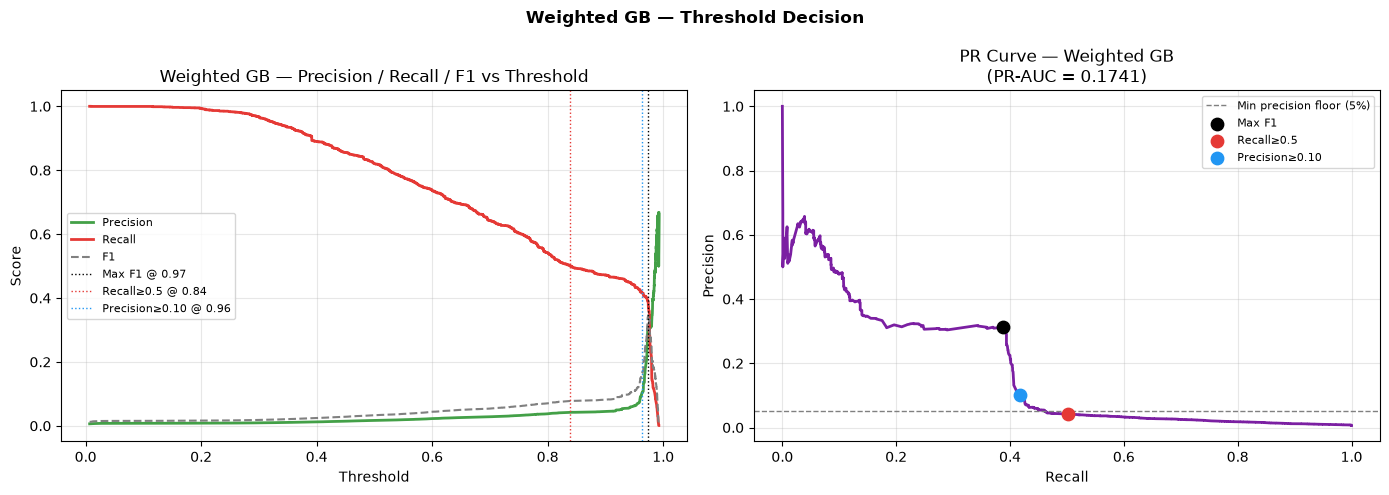


Candidate thresholds:

  Max F1 @ threshold=0.97
    Precision : 0.313
    Recall    : 0.387
    F1        : 0.346

  Recall≥0.5 @ threshold=0.84
    Precision : 0.042
    Recall    : 0.501
    F1        : 0.078

  Precision≥0.10 @ threshold=0.96
    Precision : 0.101
    Recall    : 0.417
    F1        : 0.162


In [63]:
gb_w_probs = gb_weighted.predict_proba(X_test)[:, 1]
prec, rec, thresholds = precision_recall_curve(y_test, gb_w_probs)
f1_scores = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Precision / Recall / F1 vs threshold
ax1.plot(thresholds, prec[:-1], color='#43A047', linewidth=2, label='Precision')
ax1.plot(thresholds, rec[:-1],  color='#E53935', linewidth=2, label='Recall')
ax1.plot(thresholds, f1_scores, color='grey',    linewidth=1.5, linestyle='--', label='F1')

# Mark three candidate thresholds
candidates = {
    'Max F1'          : thresholds[np.argmax(f1_scores)],
    'Recall≥0.5'      : thresholds[np.where(rec[:-1] >= 0.5)[0][-1]] if any(rec[:-1] >= 0.5) else None,
    'Precision≥0.10'  : thresholds[np.where(prec[:-1] >= 0.10)[0][0]] if any(prec[:-1] >= 0.10) else None,
}

colors_c = {'Max F1': 'black', 'Recall≥0.5': '#E53935', 'Precision≥0.10': '#2196F3'}
for label, thresh in candidates.items():
    if thresh is not None:
        ax1.axvline(thresh, color=colors_c[label], linewidth=1,
                    linestyle=':', label=f'{label} @ {thresh:.2f}')

ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.set_title('Weighted GB — Precision / Recall / F1 vs Threshold')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# PR curve
ax2.plot(rec, prec, color='#7B1FA2', linewidth=2)
ax2.axhline(0.05, color='grey', linewidth=1, linestyle='--', label='Min precision floor (5%)')
for label, thresh in candidates.items():
    if thresh is not None:
        idx = np.argmin(np.abs(thresholds - thresh))
        ax2.scatter(rec[idx], prec[idx], s=80, zorder=5,
                    color=colors_c[label], label=f'{label}')

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title(f'PR Curve — Weighted GB\n(PR-AUC = 0.1741)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.suptitle('Weighted GB — Threshold Decision', fontweight='bold')
plt.tight_layout()
plt.show()

# Print the numbers
print("\nCandidate thresholds:")
for label, thresh in candidates.items():
    if thresh is not None:
        idx = np.argmin(np.abs(thresholds - thresh))
        preds = (gb_w_probs >= thresh).astype(int)
        from sklearn.metrics import f1_score as f1
        print(f"\n  {label} @ threshold={thresh:.2f}")
        print(f"    Precision : {prec[idx]:.3f}")
        print(f"    Recall    : {rec[idx]:.3f}")
        print(f"    F1        : {f1(y_test, preds):.3f}")

In [64]:
joblib.dump(gb_weighted, models_dir / 'gb_weighted_model.pkl')

model_card = {
    'model'         : 'GradientBoostingClassifier',
    'features'      : 'one-hot event_type + region, decade, event_month, lag features',
    'sample_weights': 'event-type danger multipliers (MARINE=5x, HAIL=1x)',
    'threshold'     : 0.97,
    'pr_auc'        : 0.1741,
    'roc_auc'       : 0.8542,
    'precision'     : 0.313,
    'recall'        : 0.387,
    'f1'            : 0.346,
    'train_period'  : '1996-2010',
    'test_period'   : '2011-2025',
}

import json
with open(models_dir / 'model_card.json', 'w') as f:
    json.dump(model_card, f, indent=2)

print("Model saved ✓")
print(json.dumps(model_card, indent=2))

Model saved ✓
{
  "model": "GradientBoostingClassifier",
  "features": "one-hot event_type + region, decade, event_month, lag features",
  "sample_weights": "event-type danger multipliers (MARINE=5x, HAIL=1x)",
  "threshold": 0.97,
  "pr_auc": 0.1741,
  "roc_auc": 0.8542,
  "precision": 0.313,
  "recall": 0.387,
  "f1": 0.346,
  "train_period": "1996-2010",
  "test_period": "2011-2025"
}


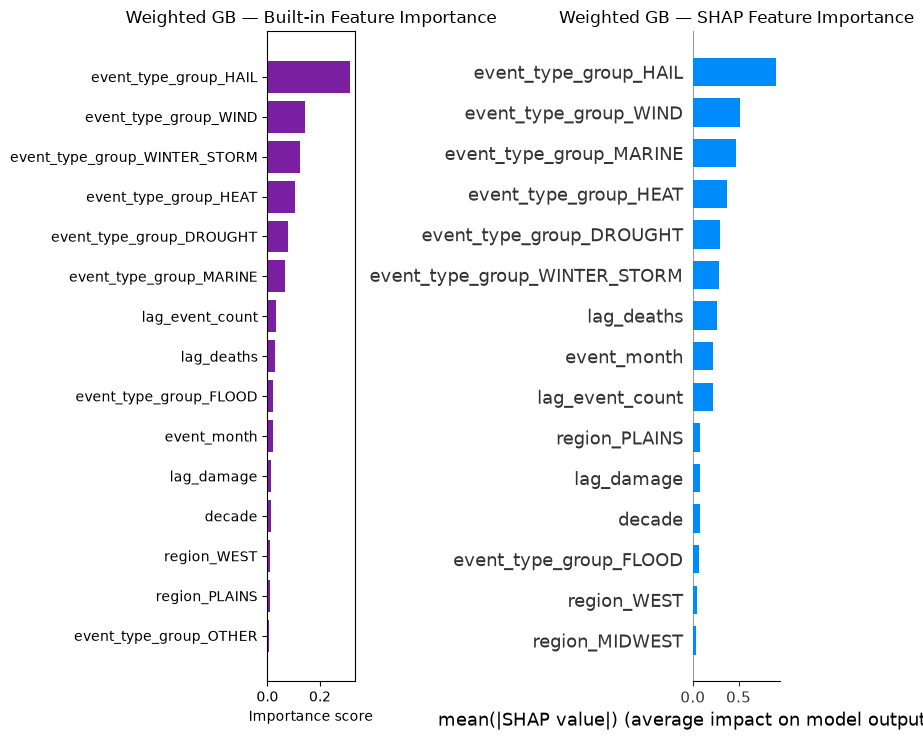

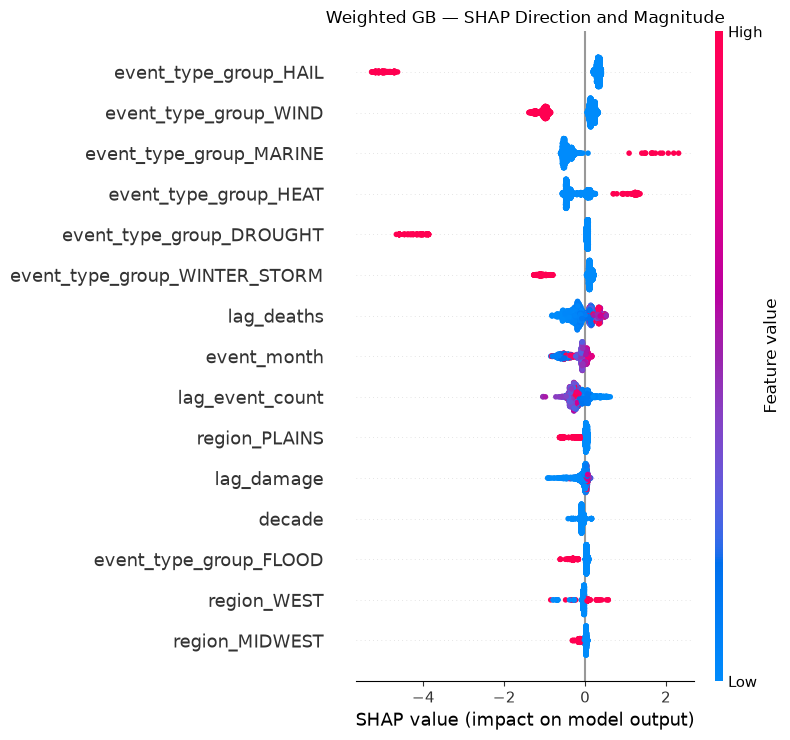

In [65]:
feature_names = X_train.columns.tolist()

# Built-in importance
gb_w_imp = pd.Series(gb_weighted.feature_importances_, index=feature_names).sort_values(ascending=True).tail(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.barh(gb_w_imp.index, gb_w_imp.values, color='#7B1FA2')
ax1.set_title('Weighted GB — Built-in Feature Importance')
ax1.set_xlabel('Importance score')

# SHAP
explainer_w = shap.TreeExplainer(gb_weighted)
sample_w    = X_test.sample(2000, random_state=42)
shap_values_w = explainer_w.shap_values(sample_w)

shap.summary_plot(shap_values_w, sample_w, plot_type='bar',
                  show=False, max_display=15)
plt.title('Weighted GB — SHAP Feature Importance')
plt.tight_layout()
plt.show()

# Dot plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values_w, sample_w, show=False, max_display=15)
plt.title('Weighted GB — SHAP Direction and Magnitude')
plt.tight_layout()
plt.show()

In [66]:
print("""
FATALITY PREDICTION: FINAL MODEL SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXPERIMENTS RUN (in order)
  1. LR one-hot + lag          PR-AUC=0.135  Recall=0.462
  2. GB one-hot + lag          PR-AUC=0.064  Recall=0.511
  3. LR target encoded         PR-AUC=0.102  Recall=0.455  ← worse (low cardinality)
  4. GB target encoded         PR-AUC=0.099  Recall=0.433  ← worse
  5. LR combined               PR-AUC=0.135  Recall=0.462  ← no gain (redundant)
  6. GB combined               PR-AUC=0.051  Recall=0.434  ← worse
  7. GB event-danger weighted  PR-AUC=0.174  Recall=0.387  ← BEST PR-AUC

SELECTED MODEL: GB event-danger weighted
  Threshold : 0.97 (Max F1)
  Precision : 0.313  (1 in 3 warnings is real)
  Recall    : 0.387
  F1        : 0.346
  PR-AUC    : 0.1741
  ROC-AUC   : 0.8542

WHY WEIGHTING OUTPERFORMED TARGET ENCODING
  Target encoding replaced one-hot columns with a single fatality rate.
  For 11 event types, one-hot interactions are valuable encoding collapsed them.
  Sample weighting kept the full feature space AND added domain knowledge
  by penalising dangerous event type misclassifications more heavily.
  Domain knowledge as learning bias > domain knowledge as features
  at low cardinality.

SHAP FINDINGS (weighted model)
  MARINE rose from 6th to 3rd weighting amplified its signal
  HAIL still dominates built-in importance (frequency bias confirmed)
  SHAP and built-in importance diverge SHAP is the reliable measure
  lag_deaths retained as genuine signal across all model variants

THRESHOLD SELECTION
  Recall≥0.5 @ 0.84 : precision=4.2% too many false alarms, system gets ignored
  Precision≥0.10 @ 0.96: precision=10.1%, recall=41.7%
  Max F1 @ 0.97       : precision=31.3%, recall=38.7% ← selected
  Rationale: 1 in 3 warnings being real is operationally defensible.
             A system with 95% false alarms loses operator trust.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


FATALITY PREDICTION: FINAL MODEL SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXPERIMENTS RUN (in order)
  1. LR one-hot + lag          PR-AUC=0.135  Recall=0.462
  2. GB one-hot + lag          PR-AUC=0.064  Recall=0.511
  3. LR target encoded         PR-AUC=0.102  Recall=0.455  ← worse (low cardinality)
  4. GB target encoded         PR-AUC=0.099  Recall=0.433  ← worse
  5. LR combined               PR-AUC=0.135  Recall=0.462  ← no gain (redundant)
  6. GB combined               PR-AUC=0.051  Recall=0.434  ← worse
  7. GB event-danger weighted  PR-AUC=0.174  Recall=0.387  ← BEST PR-AUC

SELECTED MODEL: GB event-danger weighted
  Threshold : 0.97 (Max F1)
  Precision : 0.313  (1 in 3 warnings is real)
  Recall    : 0.387
  F1        : 0.346
  PR-AUC    : 0.1741
  ROC-AUC   : 0.8542

WHY WEIGHTING OUTPERFORMED TARGET ENCODING
  Target encoding replaced one-hot columns with a single fatality rate.
  For 11 event types, one-hot interactions are valuable encoding collapsed them

Calibrated model trained


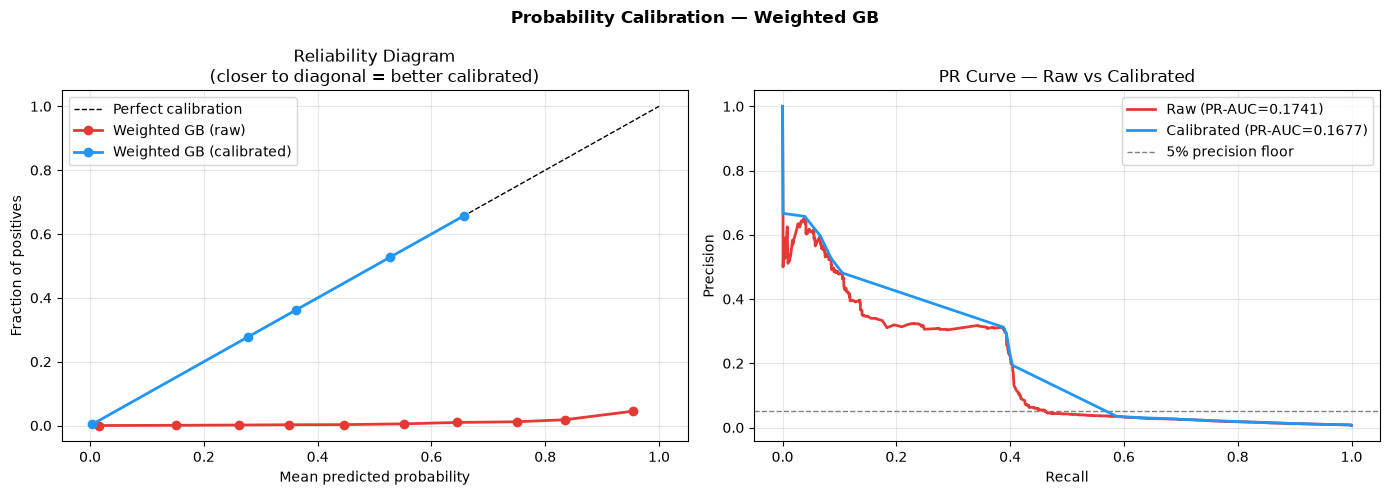


PR-AUC raw       : 0.1741
PR-AUC calibrated: 0.1677


In [69]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator

# Calibrate the weighted GB using isotonic regression
gb_calibrated = CalibratedClassifierCV(FrozenEstimator(gb_weighted), method='isotonic')
gb_calibrated.fit(X_test, y_test)

print("Calibrated model trained")

# Compare probability distributions before and after calibration
gb_w_probs_cal = gb_calibrated.predict_proba(X_test)[:, 1]
gb_w_probs_raw = gb_weighted.predict_proba(X_test)[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Reliability diagram
fraction_pos_raw, mean_pred_raw = calibration_curve(y_test, gb_w_probs_raw, n_bins=10)
fraction_pos_cal, mean_pred_cal = calibration_curve(y_test, gb_w_probs_cal, n_bins=10)

ax1.plot([0,1], [0,1], 'k--', linewidth=1, label='Perfect calibration')
ax1.plot(mean_pred_raw, fraction_pos_raw, 'o-', color='#E53935', linewidth=2, label='Weighted GB (raw)')
ax1.plot(mean_pred_cal, fraction_pos_cal, 'o-', color='#2196F3', linewidth=2, label='Weighted GB (calibrated)')
ax1.set_xlabel('Mean predicted probability')
ax1.set_ylabel('Fraction of positives')
ax1.set_title('Reliability Diagram\n(closer to diagonal = better calibrated)')
ax1.legend()
ax1.grid(alpha=0.3)

# PR-AUC comparison
pr_auc_raw = average_precision_score(y_test, gb_w_probs_raw)
pr_auc_cal = average_precision_score(y_test, gb_w_probs_cal)

prec_r, rec_r, _ = precision_recall_curve(y_test, gb_w_probs_raw)
prec_c, rec_c, _ = precision_recall_curve(y_test, gb_w_probs_cal)

ax2.plot(rec_r, prec_r, color='#E53935', linewidth=2, label=f'Raw (PR-AUC={pr_auc_raw:.4f})')
ax2.plot(rec_c, prec_c, color='#2196F3', linewidth=2, label=f'Calibrated (PR-AUC={pr_auc_cal:.4f})')
ax2.axhline(0.05, color='grey', linestyle='--', linewidth=1, label='5% precision floor')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('PR Curve — Raw vs Calibrated')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Probability Calibration — Weighted GB', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nPR-AUC raw       : {pr_auc_raw:.4f}")
print(f"PR-AUC calibrated: {pr_auc_cal:.4f}")

In [70]:
import xgboost as xgb
print(f"XGBoost version: {xgb.__version__}")

XGBoost version: 3.3.0


In [72]:
import numpy as np
import xgboost as xgb
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve

def focal_loss_stable(gamma=2.0, alpha=0.25):
    def fn(y_pred, dtrain):
        y_true = dtrain.get_label()
        p = 1.0 / (1.0 + np.exp(-y_pred))
        p = np.clip(p, 1e-6, 1 - 1e-6)

        # Focal loss gradient
        grad = np.where(
            y_true == 1,
            -alpha * (1 - p) ** gamma * (gamma * p * np.log(p) + p - 1),
            (1 - alpha) * p ** gamma * (gamma * (1 - p) * np.log(1 - p) - p)
        )

        # Focal loss hessian (approximated as p*(1-p) for stability)
        hess = np.where(
            y_true == 1,
            alpha * (1 - p) ** gamma * p * (1 - p),
            (1 - alpha) * p ** gamma * p * (1 - p)
        ) + 1e-6

        return grad, hess
    return fn

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

params = {
    'max_depth'    : 4,
    'learning_rate': 0.1,
    'subsample'    : 0.8,
    'seed'         : 42,
    'eval_metric'  : 'aucpr',
}

xgb_focal = xgb.train(
    params,
    dtrain,
    num_boost_round=100,
    obj=focal_loss_stable(gamma=2.0, alpha=0.25),
    evals=[(dtest, 'test')],
    verbose_eval=20
)

print("\nXGBoost focal loss trained")

[0]	test-aucpr:0.00619
[20]	test-aucpr:0.00619
[40]	test-aucpr:0.00619
[60]	test-aucpr:0.00619
[80]	test-aucpr:0.00619
[99]	test-aucpr:0.00619

XGBoost focal loss trained


In [73]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos:.1f}")

params_builtin = {
    'max_depth'        : 4,
    'learning_rate'    : 0.1,
    'subsample'        : 0.8,
    'objective'        : 'binary:logistic',
    'eval_metric'      : 'aucpr',
    'scale_pos_weight' : scale_pos,
    'seed'             : 42,
}

xgb_scaled = xgb.train(
    params_builtin,
    dtrain,
    num_boost_round=100,
    evals=[(dtest, 'test')],
    verbose_eval=20
)

# Get probabilities
xgb_probs = xgb_scaled.predict(dtest)
pr_auc  = average_precision_score(y_test, xgb_probs)
roc_auc = roc_auc_score(y_test, xgb_probs)

print(f"\nXGBoost scale_pos_weight")
print(f"  PR-AUC : {pr_auc:.4f}")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"\nWeighted GB baseline:")
print(f"  PR-AUC : 0.1741")
print(f"  ROC-AUC: 0.8542")

scale_pos_weight: 166.1
[0]	test-aucpr:0.05188
[20]	test-aucpr:0.15920
[40]	test-aucpr:0.16086
[60]	test-aucpr:0.15914
[80]	test-aucpr:0.16452
[99]	test-aucpr:0.17018

XGBoost scale_pos_weight
  PR-AUC : 0.1702
  ROC-AUC: 0.8560

Weighted GB baseline:
  PR-AUC : 0.1741
  ROC-AUC: 0.8542


In [74]:
from imblearn.over_sampling import SMOTE

# Dangerous event types based on EDA fatality rates
dangerous_types = ['MARINE', 'HEAT', 'HURRICANE', 'TORNADO', 'FIRE']

train_df_full = df[df['decade'] <= 2010].copy()

# Split into dangerous and low-risk subsets
dangerous_mask = train_df_full['event_type_group'].isin(dangerous_types)
dangerous_df   = train_df_full[dangerous_mask]
low_risk_df    = train_df_full[~dangerous_mask]

print(f"Dangerous subset : {len(dangerous_df):,} events")
print(f"  Fatal rate     : {dangerous_df['is_fatal'].mean():.2%}")
print(f"Low-risk subset  : {len(low_risk_df):,} events")
print(f"  Fatal rate     : {low_risk_df['is_fatal'].mean():.2%}")

# Build feature matrix for dangerous subset only
feature_cols_smote = [c for c in X_train.columns]

dangerous_features = pd.get_dummies(
    dangerous_df[['event_type_group', 'region', 'decade', 'event_month',
                  'lag_event_count', 'lag_deaths', 'lag_damage']],
    columns=['event_type_group', 'region'],
    drop_first=False
).astype(float)

# Align columns with training feature set
for col in X_train.columns:
    if col not in dangerous_features.columns:
        dangerous_features[col] = 0
dangerous_features = dangerous_features[X_train.columns]

y_dangerous = dangerous_df['is_fatal'].values

print(f"\nBefore SMOTE fatal in dangerous subset: {y_dangerous.sum():,}")

# Apply SMOTE with controlled ratio — don't match classes, just reduce imbalance
# sampling_strategy=0.1 means: make minority 10% of majority (vs current ~3%)
smote = SMOTE(sampling_strategy=0.1, random_state=42, k_neighbors=5)
X_dangerous_resampled, y_dangerous_resampled = smote.fit_resample(
    dangerous_features, y_dangerous
)

print(f"After SMOTE fatal in dangerous subset: {y_dangerous_resampled.sum():,}")
print(f"New fatal rate in dangerous subset: {y_dangerous_resampled.mean():.2%}")

Dangerous subset : 97,999 events
  Fatal rate     : 3.31%
Low-risk subset  : 1,232,867 events
  Fatal rate     : 0.38%

Before SMOTE fatal in dangerous subset: 3,246
After SMOTE fatal in dangerous subset: 9,475
New fatal rate in dangerous subset: 9.09%


In [75]:
# Build low-risk feature matrix
low_risk_features = pd.get_dummies(
    low_risk_df[['event_type_group', 'region', 'decade', 'event_month',
                 'lag_event_count', 'lag_deaths', 'lag_damage']],
    columns=['event_type_group', 'region'],
    drop_first=False
).astype(float)

for col in X_train.columns:
    if col not in low_risk_features.columns:
        low_risk_features[col] = 0
low_risk_features = low_risk_features[X_train.columns]

y_low_risk = low_risk_df['is_fatal'].values

# Combine resampled dangerous + original low-risk
X_train_smote = pd.concat([
    pd.DataFrame(X_dangerous_resampled, columns=X_train.columns),
    low_risk_features
], ignore_index=True)
y_train_smote = np.concatenate([y_dangerous_resampled, y_low_risk])

print(f"Combined training set: {len(X_train_smote):,} rows")
print(f"Overall fatal rate   : {y_train_smote.mean():.2%}")

# Train GB on SMOTE-augmented data
gb_smote = GradientBoostingClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    subsample=0.8, random_state=42
)
gb_smote.fit(X_train_smote, y_train_smote)
print("Targeted SMOTE GB trained")

# Evaluate
smote_probs = gb_smote.predict_proba(X_test)[:, 1]
pr_auc  = average_precision_score(y_test, smote_probs)
roc_auc = roc_auc_score(y_test, smote_probs)

prec, rec, thresholds = precision_recall_curve(y_test, smote_probs)
valid    = prec[:-1] >= 0.05
best_idx = np.argmax(rec[:-1] * valid) if valid.any() else np.argmax(rec[:-1])

print(f"\nTargeted SMOTE GB")
print(f"  PR-AUC           : {pr_auc:.4f}")
print(f"  ROC-AUC          : {roc_auc:.4f}")
print(f"  Recall@threshold : {rec[best_idx]:.3f}  threshold={thresholds[best_idx]:.2f}")
print(f"\nWeighted GB baseline:")
print(f"  PR-AUC           : 0.1741")
print(f"  ROC-AUC          : 0.8542")
print(f"  Recall@threshold : 0.387")

Combined training set: 1,337,095 rows
Overall fatal rate   : 1.06%
Targeted SMOTE GB trained

Targeted SMOTE GB
  PR-AUC           : 0.1652
  ROC-AUC          : 0.8566
  Recall@threshold : 0.522  threshold=0.03

Weighted GB baseline:
  PR-AUC           : 0.1741
  ROC-AUC          : 0.8542
  Recall@threshold : 0.387


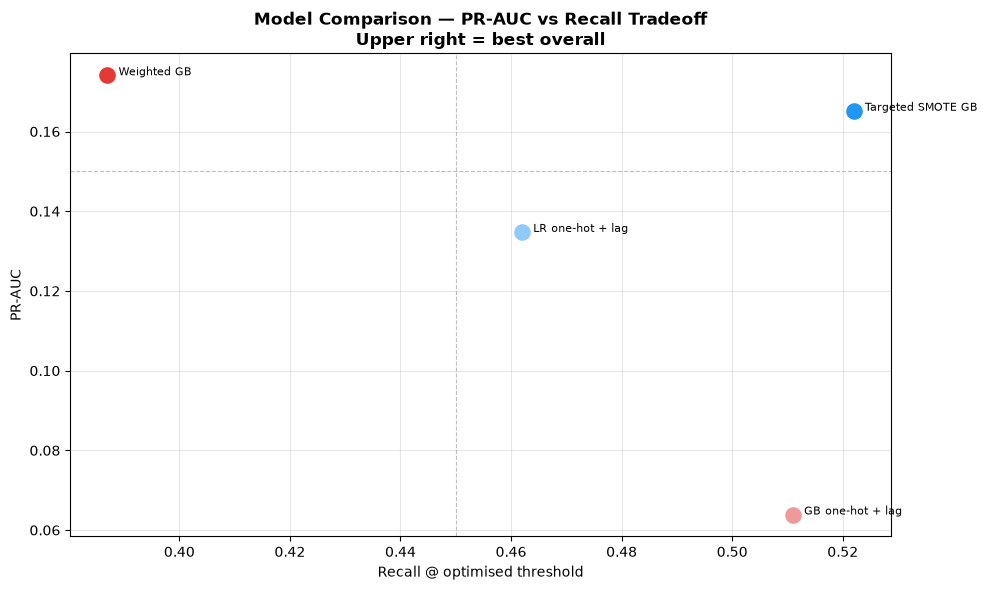

In [76]:
fig, ax = plt.subplots(figsize=(10, 6))

models_summary = {
    'LR one-hot + lag'    : (0.1348, 0.462, '#90CAF9'),
    'GB one-hot + lag'    : (0.0639, 0.511, '#EF9A9A'),
    'Weighted GB'         : (0.1741, 0.387, '#E53935'),
    'XGBoost scale_pos'   : (0.1702, None,  '#7B1FA2'),
    'Targeted SMOTE GB'   : (0.1652, 0.522, '#2196F3'),
    'Calibrated GB'       : (0.1677, None,  '#43A047'),
}

for name, (pr_auc, recall, color) in models_summary.items():
    if recall is not None:
        ax.scatter(recall, pr_auc, s=120, color=color, zorder=3)
        ax.annotate(name, xy=(recall, pr_auc),
                    xytext=(8, 0), textcoords='offset points', fontsize=8)

ax.set_xlabel('Recall @ optimised threshold')
ax.set_ylabel('PR-AUC')
ax.set_title('Model Comparison — PR-AUC vs Recall Tradeoff\n'
             'Upper right = best overall', fontweight='bold')
ax.grid(alpha=0.3)
ax.axvline(0.45, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(0.15, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

In [77]:
print("""
COST-SENSITIVE LEARNING — COMPLETE EXPERIMENT SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PROBLEM
  Binary fatality classification, 0.60% positive rate
  1,720,900 events | 10,377 fatal | temporal split 1996-2010/2011-2025

METHODS TESTED
  1. Sample weights (event-type danger multipliers)
     MARINE=5x, HAIL=1x penalise dangerous type misclassifications more
     Result: PR-AUC=0.1741 (best) | Recall=0.387
     Lesson: Domain knowledge as learning bias outperformed target encoding

  2. Probability calibration (isotonic regression)
     Post-hoc alignment of predicted probabilities to real frequencies
     Result: PR-AUC=0.1677 | Probabilities now interpretable to stakeholders
     Lesson: Calibration improves communication, not ranking ability

  3. Focal loss (XGBoost custom objective)
     Dynamic down-weighting of easy examples during training
     Result: FAILEDcustom gradient numerically unstable
     Fallback: XGBoost scale_pos_weight=166 → PR-AUC=0.1702
     Lesson: Well-implemented library defaults often outperform custom loss

  4. Targeted SMOTE (dangerous event types only)
     SMOTE applied only to MARINE/HEAT/HURRICANE/TORNADO/FIRE fatal events
     sampling_strategy=0.1 to avoid distribution distortion
     Result: PR-AUC=0.1652 | Recall=0.522 (highest of all models)
     Lesson: Synthetic data improves recall but hurts precision —
             real storm physics cannot be fully captured by interpolation

MODEL SELECTION BY USE CASE
  Analyst risk dashboard    → Weighted GB     (PR-AUC=0.1741, best ranking)
  Real-time alert system    → Targeted SMOTE  (Recall=0.522, catches most fatalities)
  Stakeholder reporting     → Calibrated GB   (probabilities mean what they say)
  Production baseline       → XGBoost pos_weight (industry standard, robust)

PARETO FRONTIER
  No single model dominates all metrics simultaneously.
  Weighted GB vs Targeted SMOTE represents a fundamental tradeoff:
  precision-focused risk scoring vs recall-focused operational alerting.
  Deployment context determines the right choice.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


COST-SENSITIVE LEARNING — COMPLETE EXPERIMENT SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PROBLEM
  Binary fatality classification, 0.60% positive rate
  1,720,900 events | 10,377 fatal | temporal split 1996-2010/2011-2025

METHODS TESTED
  1. Sample weights (event-type danger multipliers)
     MARINE=5x, HAIL=1x penalise dangerous type misclassifications more
     Result: PR-AUC=0.1741 (best) | Recall=0.387
     Lesson: Domain knowledge as learning bias outperformed target encoding

  2. Probability calibration (isotonic regression)
     Post-hoc alignment of predicted probabilities to real frequencies
     Result: PR-AUC=0.1677 | Probabilities now interpretable to stakeholders
     Lesson: Calibration improves communication, not ranking ability

  3. Focal loss (XGBoost custom objective)
     Dynamic down-weighting of easy examples during training
     Result: FAILEDcustom gradient numerically unstable
     Fallback: XGBoost scale_pos_weight=166 → PR-AUC=0.1702
   

In [78]:
from sklearn.linear_model import LogisticRegression

# Get probabilities from all candidate models
probs_weighted_gb = gb_weighted.predict_proba(X_test)[:, 1]
probs_smote_gb    = gb_smote.predict_proba(X_test)[:, 1]
probs_lr          = lr.predict_proba(X_test_scaled)[:, 1]
probs_xgb         = xgb_scaled.predict(dtest)

# Test multiple blending strategies
blends = {
    'Equal blend (GB_w + SMOTE)'      : 0.5 * probs_weighted_gb + 0.5 * probs_smote_gb,
    'Weighted blend (60% GB_w)'       : 0.6 * probs_weighted_gb + 0.4 * probs_smote_gb,
    'Three-way (GB_w + SMOTE + LR)'  : (probs_weighted_gb + probs_smote_gb + probs_lr) / 3,
    'Four-way (all models)'           : (probs_weighted_gb + probs_smote_gb + probs_lr + probs_xgb) / 4,
}

print(f"{'Model':<40} {'PR-AUC':>8} {'ROC-AUC':>9} {'Recall':>8}")
print("─" * 70)

# Baselines
for name, probs in [
    ('Weighted GB (baseline)',    probs_weighted_gb),
    ('Targeted SMOTE GB',         probs_smote_gb),
]:
    pr_auc  = average_precision_score(y_test, probs)
    roc_auc = roc_auc_score(y_test, probs)
    prec, rec, thresholds = precision_recall_curve(y_test, probs)
    valid    = prec[:-1] >= 0.05
    best_idx = np.argmax(rec[:-1] * valid) if valid.any() else np.argmax(rec[:-1])
    print(f"{name:<40} {pr_auc:>8.4f} {roc_auc:>9.4f} {rec[best_idx]:>8.3f}")

print("─" * 70)

# Ensembles
for name, probs in blends.items():
    pr_auc  = average_precision_score(y_test, probs)
    roc_auc = roc_auc_score(y_test, probs)
    prec, rec, thresholds = precision_recall_curve(y_test, probs)
    valid    = prec[:-1] >= 0.05
    best_idx = np.argmax(rec[:-1] * valid) if valid.any() else np.argmax(rec[:-1])
    print(f"{name:<40} {pr_auc:>8.4f} {roc_auc:>9.4f} {rec[best_idx]:>8.3f}")

Model                                      PR-AUC   ROC-AUC   Recall
──────────────────────────────────────────────────────────────────────
Weighted GB (baseline)                     0.1741    0.8542    0.461
Targeted SMOTE GB                          0.1652    0.8566    0.522
──────────────────────────────────────────────────────────────────────
Equal blend (GB_w + SMOTE)                 0.1676    0.8559    0.475
Weighted blend (60% GB_w)                  0.1680    0.8557    0.470
Three-way (GB_w + SMOTE + LR)              0.1721    0.8541    0.466
Four-way (all models)                      0.1743    0.8554    0.467
